In [5]:
## Importing
import warnings

warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

import numpy as np
import pandas as pd
from evclust.utils import plotting
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from evclust.utils import display_results_evidential, display_results_fuzzy_partition
from evclust.datasets import load_toys3c2d

from evclust.ecm import ecm
from evclust.wecm_new_barycenter import wecm
from evclust.wecm_new_barycenter_2 import wecm as wecm2
from evclust.gwecm import gwecm
from evclust.fcm.fcm_keller2000 import fcm as fcm_keller2000
from evclust.fcm.fcm_wang2004 import fcm as fcm_wang2004
from evclust.fcm.fcm_frigui2004 import scad1
from evclust.fcm.fcm_frigui2004 import scad2
from evclust.fcm.ifwfcm_xing2014 import fcm as ifwfcm_xing2014
from evclust.fcm.ifwfcm_kd_xing2014 import fcm as ifwfcm_kd_xing2014

Instances: 600; Features: 2; Clusters: 2    3
dtype: int64
Instances 600 - Features 2 - Class 3
          0         1
0  1.332986 -1.065965
1 -0.057020 -1.263599
2  0.701903 -0.636676
3  0.372527 -0.686493
4  1.560163 -0.925505


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


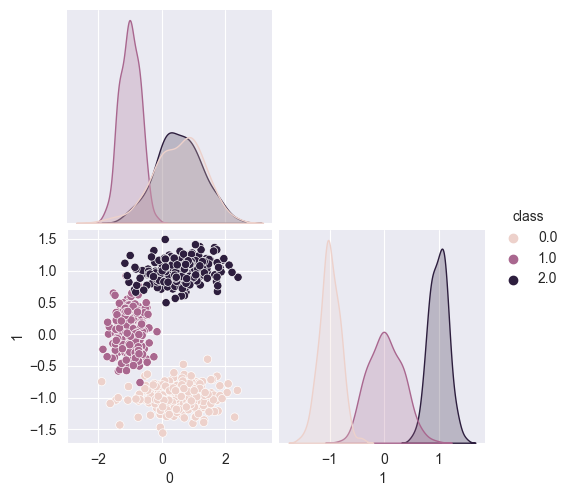

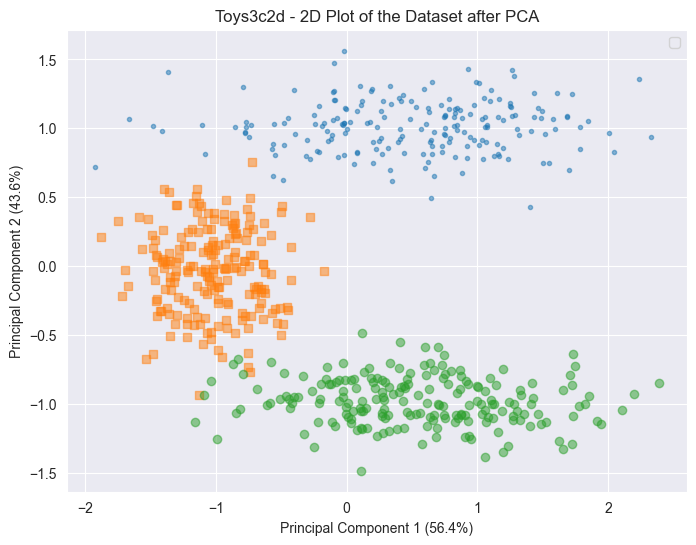

In [6]:
# fetch dataset 
df = load_toys3c2d()

# data (as pandas dataframes) 
X = df.iloc[:, :-1]
y = pd.DataFrame(df.iloc[:, -1])
c = 3

print(f"Instances: {X.shape[0]}; Features: {X.shape[1]}; Clusters: {y.nunique()}")
plotting(X, y, "Toys3c2d", matrix_plot=True)

label_column_nm = y.columns[0]
labels_encoder = LabelEncoder()
numeric_labels = labels_encoder.fit_transform(y[label_column_nm])

# Normalization
scaler = MinMaxScaler((0, 1))
X = pd.DataFrame(scaler.fit_transform(X))

# ECM

In [7]:
%%capture
# Traditional ECM clustering
delta = np.sqrt(20)
ecm_models = np.array([])
for i in range(10):
    model = ecm(x=X, c=c, beta=2, alpha=1, delta=delta, init="None")
    ecm_models = np.append(ecm_models, model)

ecm_models = sorted(ecm_models, key=lambda x: x['crit'])

J values: [7.4072154777996255, 7.4073993538344585, 7.408104455080007, 7.408176624076924, 7.40821326309426, 7.408265083044634, 7.408340901636463, 7.408494952985727, 7.408613723130054, 7.408615186689664]
ARI values: [0.8676058767022532, 0.8629396080365563, 0.8682915024376422, 0.8682915024376422, 0.8682915024376422, 0.8676058767022532, 0.8626728610697282, 0.8682915024376422, 0.8577676299406468, 0.8577676299406468]
NS values: [1.0225723053104132, 1.022692931947398, 1.0147308544335563, 1.1431214996907373, 1.1431443977098847, 1.0799373836794661, 1.0799951941759476, 1.0149980991702827, 1.0115003871660537, 1.0801755947826583]
NMI values: [0.8491357601557324, 0.8453778690874882, 0.8513104262372257, 0.8513104262372257, 0.8513104262372257, 0.8491357601557326, 0.8445766314454172, 0.8513104262372257, 0.8401541798395977, 0.8401541798395977]


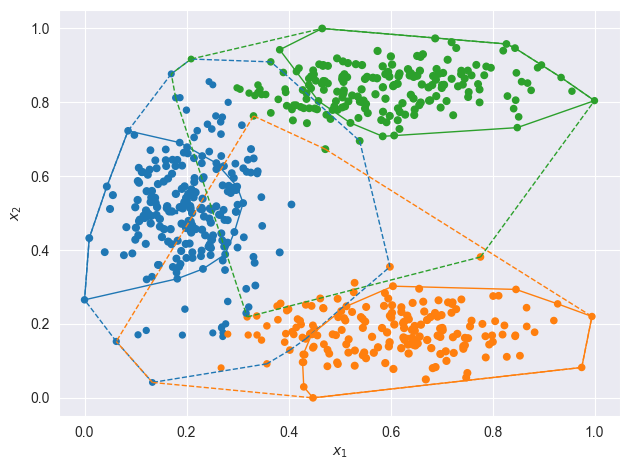

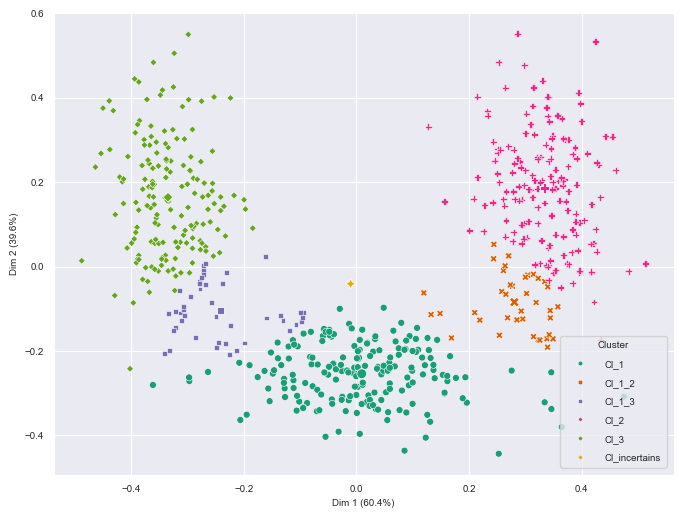

In [8]:

display_results_evidential(X, ecm_models, numeric_labels)

# WECM

In [9]:
%%capture
wecm_models = np.array([])
d = X.shape[1]
delta = np.sqrt(20)
for i in range(10):
    model = wecm(x=X, c=c, beta=2, alpha=1, delta=delta, init="None")
    wecm_models = np.append(wecm_models, model)

wecm_models = sorted(wecm_models, key=lambda model: model['crit'])

J values: [0.7884406036495077, 0.8523453770178345, 0.8815104339417319, 0.9087486776638829, 0.9130337950692706, 0.9130983684163558, 0.9272325846860456, 1.0412714014853415, 1.0413669090765383, 1.1674890311456783]
ARI values: [0.950525005824116, 0.9460384390576054, 0.9355468993229582, 0.955765361672674, 0.6911928098495905, 0.6911928098495905, 0.5287785146937093, 0.38250994687578443, 0.38250994687578443, 0.6955073739183146]
NS values: [1.5083203530174119, 1.3959571423180606, 1.625889762871702, 1.4343061136172286, 1.7809481697674865, 1.7172325252919283, 1.4181221768431447, 1.4181356749259637, 1.4448100856397337, 1.7079239106517776]
NMI values: [0.922939523321827, 0.9206980098869758, 0.9085722053076157, 0.9313580083372959, 0.6480817975647344, 0.6480817975647342, 0.6306973275792881, 0.38816829794463686, 0.38816829794463686, 0.6892392554018477]


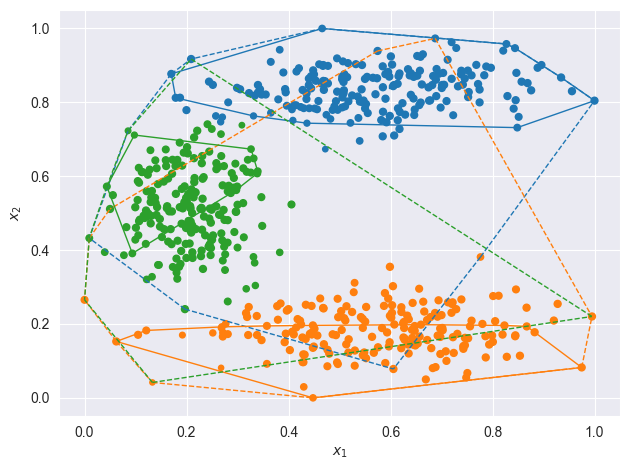

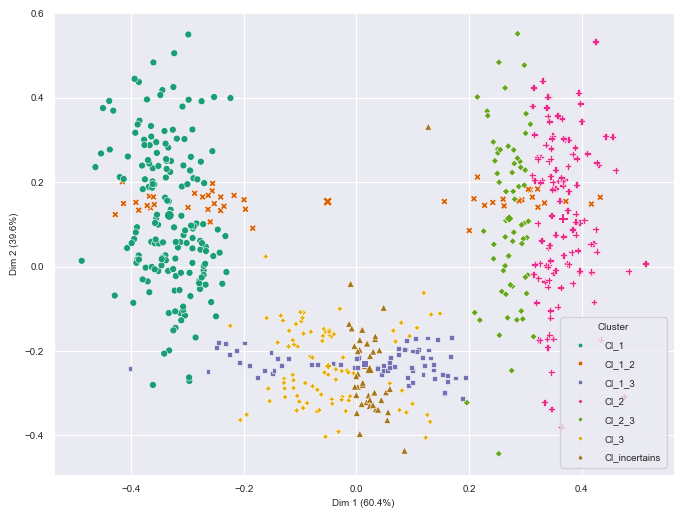

In [10]:
display_results_evidential(X, wecm_models, numeric_labels)

# WECM2

In [31]:
%%capture
wecm_models = np.array([])
d = X.shape[1]
delta = np.sqrt(20)
for i in range(10):
    model = wecm2(x=X, c=c, beta=2, alpha=1, delta=delta, init="None", epsilon=1e-3, stopping_factor="center")
    wecm_models = np.append(wecm_models, model)

wecm_models = sorted(wecm_models, key=lambda model: model['crit'])

J values: [1.170761074892685, 1.1755725381526134, 1.1772664526787446, 1.1782418548021356, 1.1800395728578466, 1.1813933714380194, 1.184902536430662, 1.2051741392270061, 1.2395181890976912, 3.171096762018406]
ARI values: [0.9702260874837869, 0.9702260874837869, 0.9702260874837869, 0.9652970671245503, 0.9702260874837869, 0.9653218586747573, 0.9653218586747573, 0.9603934221877839, 0.9653218586747573, 0.8091644996725688]
NS values: [1.4927260567581466, 1.487690185759107, 1.488476279531645, 1.4746168786908547, 1.466136839379955, 1.5508292303995215, 1.4888215823217736, 1.491151924361535, 1.4686138375312763, 1.077651389195146]
NMI values: [0.9477229699770433, 0.9477229699770433, 0.9477229699770433, 0.940286458949442, 0.9477229699770435, 0.940294477291009, 0.940294477291009, 0.9336433448792226, 0.940294477291009, 0.8034786078583581]


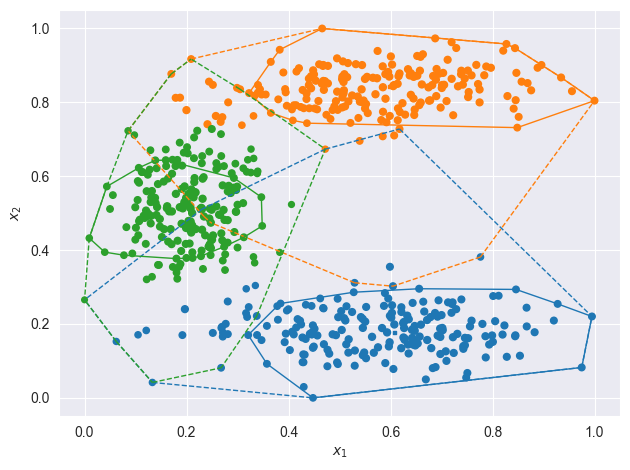

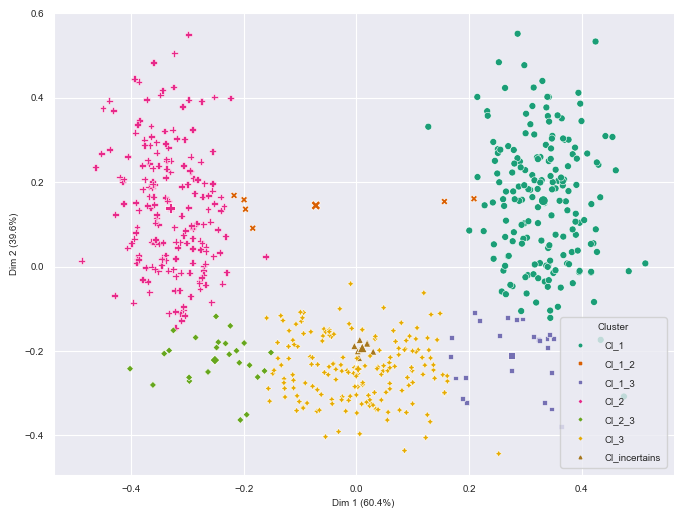

In [32]:
display_results_evidential(X, wecm_models, numeric_labels)

# Global weighted ECM - GWECM

In [13]:
%%capture
gwecm_models = np.array([])
d = X.shape[1]
delta = np.sqrt(20)
for i in range(10):
    model = gwecm(x=X, c=c, beta=2, alpha=1, delta=delta, init="kmeans", epsilon=1e-4)
    gwecm_models = np.append(gwecm_models, model)

gwecm_models = sorted(gwecm_models, key=lambda model: model['crit'])

J values: [0.9998302062313795, 0.9998302062313795, 0.9998302062313795, 0.9998302062313795, 0.9998302062313797, 0.9998302062313809, 0.999830206231382, 0.9998302062313827, 0.9998302062313827, 1.01464242388286]
ARI values: [0.5305445585023766, 0.5305445585023766, 0.5305445585023766, 0.5305445585023766, 0.5305445585023766, 0.5305445585023766, 0.5305445585023766, 0.5305445585023766, 0.5305445585023766, 0.5358770540993749]
NS values: [1.301423780798734, 1.301423780798734, 1.301423780798734, 1.301423780798734, 1.2007213248205035, 1.2978308133039689, 1.1895771401193762, 1.4312626030486517, 1.4312626030486517, 1.4440873144882513]
NMI values: [0.6293552436606972, 0.6293552436606972, 0.6293552436606972, 0.6293552436606972, 0.6293552436606972, 0.6293552436606972, 0.6293552436606972, 0.6293552436606972, 0.6293552436606972, 0.6258912489174033]


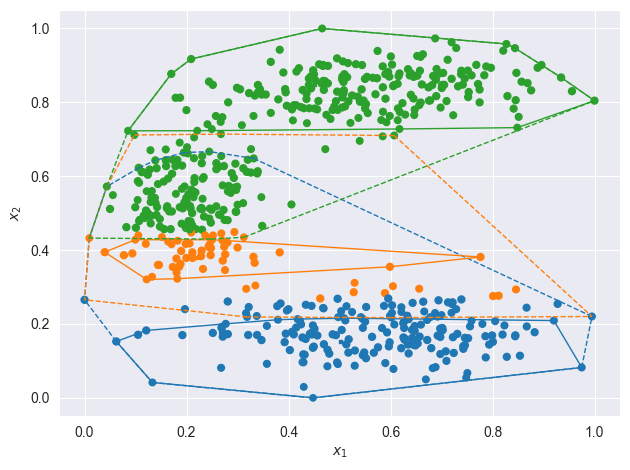

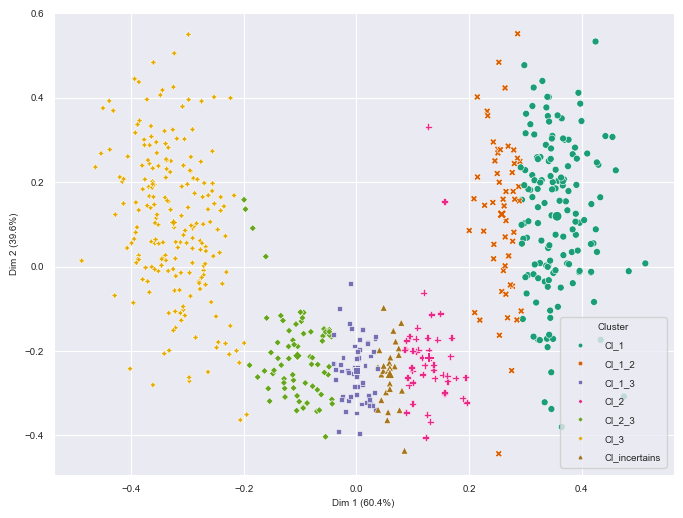

In [14]:
display_results_evidential(X, gwecm_models, numeric_labels)

# Weighted FCM - Keller et al. 2000

In [15]:
%%capture
keller_models = np.array([])
w0 = np.ones((c, X.shape[1])) / X.shape[1]
for i in range(10):
    model = fcm_keller2000(X, c=c, w0=w0, verbose=True, init="None")
    keller_models = np.append(keller_models, model)
keller_models = sorted(keller_models, key=lambda model: model['obj_func'])

J values: [1.630199952822768, 1.630217612574079, 1.6302500095971744, 1.6302553581747188, 1.6302664706787153, 2.456659225424422, 2.4569923434538232, 2.4570746554860783, 2.4572016302816593, 2.4573010576656023]
ARI values: [0.9653218586747573, 0.9653218586747573, 0.960380380308701, 0.960380380308701, 0.960380380308701, 0.3845228340567844, 0.38959456776012935, 0.38959456776012935, 0.38959456776012935, 0.38959456776012935]
NMI values: [0.940294477291009, 0.940294477291009, 0.932854011512246, 0.9328540115122462, 0.932854011512246, 0.3917286202367263, 0.3971401511705429, 0.3971401511705429, 0.3971401511705429, 0.3971401511705429]


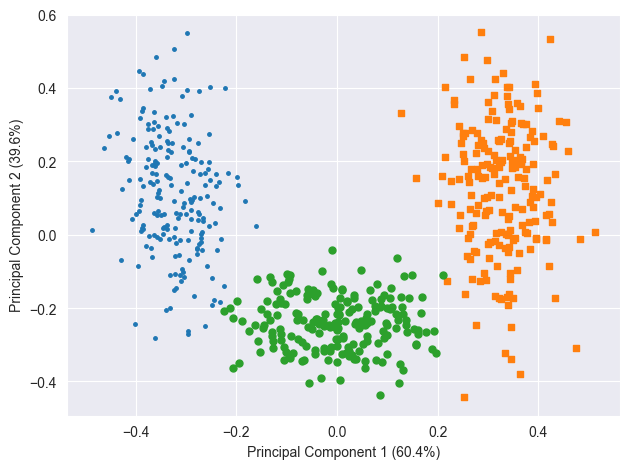

In [16]:
display_results_fuzzy_partition(X, keller_models, numeric_labels)

# WFCM Wang2004

In [17]:
%%capture
wang_models = np.array([])
for i in range(2):
    model = fcm_wang2004(X, c, w_beta=2.8, verbose=True, init="None")
    wang_models = np.append(wang_models, model)

J values: [2.87101207160432, 2.871076741236574]
ARI values: [0.8964130583891101, 0.8964130583891101]
NMI values: [0.8746529809080851, 0.8746529809080851]


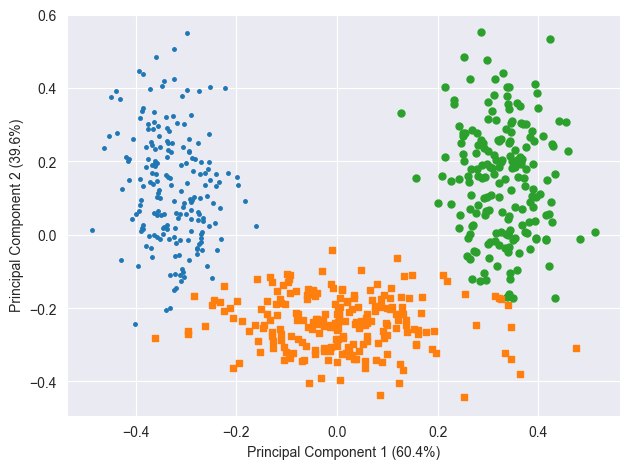

In [18]:
display_results_fuzzy_partition(X, wang_models, numeric_labels)

# SCAD1

In [19]:
%%capture
scad1_models = np.array([])
for i in range(10):
    model = scad1(X, c, verbose=True, init="None")
    scad1_models = np.append(scad1_models, model)
scad1_models = sorted(scad1_models, key=lambda model: model['obj_func'])

J values: [15.628499142669654, 15.628612811391807, 15.628875226266956, 15.629105015918038, 15.62914752000215, 15.629225462968607, 15.629308158087852, 15.629528595276359, 15.629537778745222, 15.629580355141895]
ARI values: [0.9255166064990333, 0.9255166064990333, 0.9255166064990333, 0.9255166064990333, 0.9255166064990333, 0.9255166064990333, 0.9255166064990333, 0.9255166064990333, 0.9255166064990333, 0.9255166064990333]
NMI values: [0.9023160859831857, 0.9023160859831857, 0.9023160859831859, 0.9023160859831858, 0.9023160859831857, 0.9023160859831857, 0.9023160859831857, 0.9023160859831858, 0.9023160859831857, 0.9023160859831857]


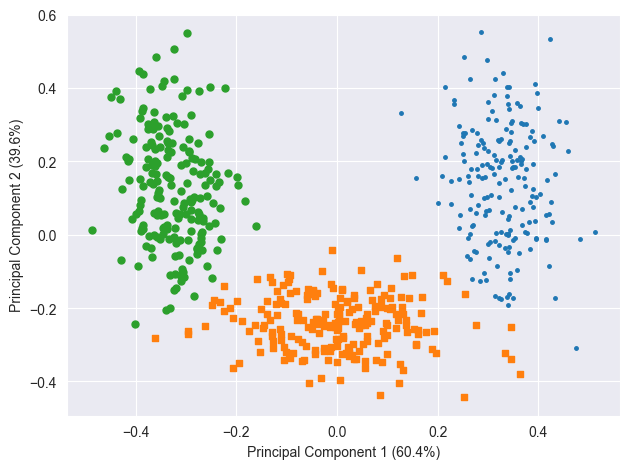

In [20]:
display_results_fuzzy_partition(X, scad1_models, numeric_labels)

# SCAD2

In [29]:
%%capture
scad2_models = np.array([])
for i in range(10):
    model = scad2(X, c, verbose=True, init="None")
    scad2_models = np.append(scad2_models, model)
scad2_models = sorted(scad2_models, key=lambda model: model['obj_func'])

J values: [1.6846498519484299, 1.6846863422677059, 1.6847268650093792, 1.6847553191294, 1.6848292494828394, 1.6848878859987368, 1.6849435644056119, 1.6849619464851475, 1.6851132047998023, 1.6851169623749687]
ARI values: [0.9653218586747573, 0.9653218586747573, 0.9702886707690855, 0.9751797317603417, 0.9653218586747573, 0.9653218586747573, 0.9653218586747573, 0.9653218586747573, 0.9653218586747573, 0.9653218586747573]
NMI values: [0.940294477291009, 0.940294477291009, 0.9498376878270723, 0.9564769719453766, 0.940294477291009, 0.940294477291009, 0.940294477291009, 0.940294477291009, 0.940294477291009, 0.940294477291009]


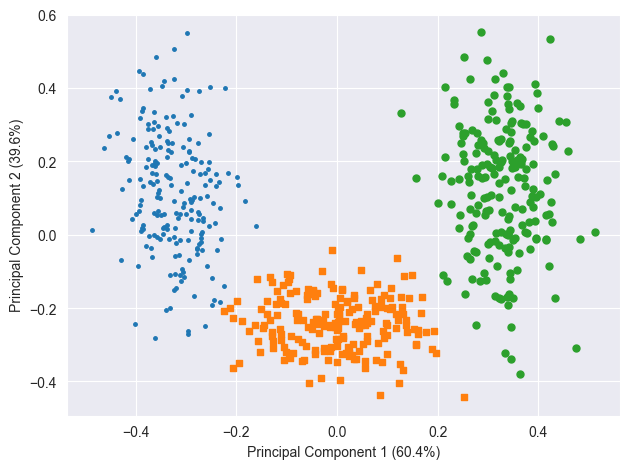

In [30]:
display_results_fuzzy_partition(X, scad2_models, numeric_labels)

# IFWFCM - Xing et al. 2014

In [23]:
%%capture
ifwfcm_models = np.array([])
for i in range(10):
    model = ifwfcm_xing2014(X, c, verbose=True, init="None", epsilon=1e-6)
    ifwfcm_models = np.append(ifwfcm_models, model)
ifwfcm_models = sorted(ifwfcm_models, key=lambda model: model['obj_func'])

J values: [3.0101403552986183, 3.0101448864280105, 3.0157267218767303, 3.015726735825897, 3.015727335905368, 3.0157273629239203, 3.015745210948841, 3.015745429081018, 3.0157457763094966, 3.0157459670976383]
ARI values: [0.39091267144855746, 0.39091267144855746, 0.8150795760822145, 0.8150795760822145, 0.8150795760822145, 0.8150795760822145, 0.8150795760822145, 0.8150795760822145, 0.8150795760822145, 0.8150795760822145]
NMI values: [0.3971601942487723, 0.3971601942487723, 0.8054639599121333, 0.8054639599121333, 0.805463959912133, 0.805463959912133, 0.805463959912133, 0.805463959912133, 0.8054639599121333, 0.805463959912133]


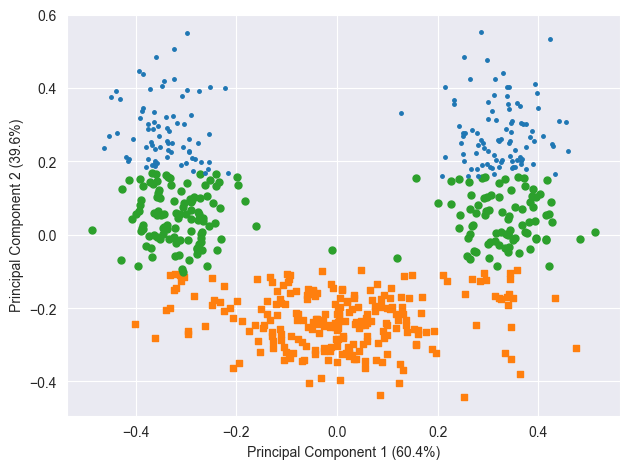

In [24]:
display_results_fuzzy_partition(X, ifwfcm_models, numeric_labels)

# IFWFCM_KD Xing 2014

In [25]:
%%capture
ifwfcm_kd_models = np.array([])
for i in range(10):
    model = ifwfcm_kd_xing2014(X, c, verbose=True, epsilon=1e-6, init="None")
    ifwfcm_kd_models = np.append(ifwfcm_kd_models, model)
ifwfcm_kd_models = sorted(ifwfcm_kd_models, key=lambda model: model['obj_func'])

J values: [31.186373329896913, 31.186373404638893, 31.18637350470139, 31.186373519189445, 31.186373541004365, 36.714786803742705, 36.71478696999282, 36.7147870258559, 36.71479263529734, 36.71479268780651]
ARI values: [0.9654283040864275, 0.9654283040864275, 0.9654283040864275, 0.9654283040864275, 0.9654283040864275, 0.3850606609538469, 0.3850606609538469, 0.3850606609538469, 0.3850606609538469, 0.3850606609538469]
NMI values: [0.9494408511975146, 0.9494408511975146, 0.9494408511975146, 0.9494408511975146, 0.9494408511975146, 0.3889141716098019, 0.38891417160980185, 0.38891417160980185, 0.38891417160980185, 0.38891417160980185]


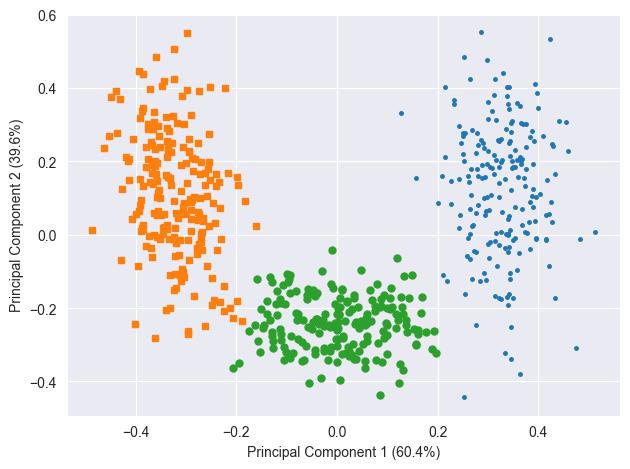

In [26]:
display_results_fuzzy_partition(X, ifwfcm_kd_models, numeric_labels)